**25MML0014**

In [8]:
import tensorflow as tf
import os
import numpy as np
import xml.etree.ElementTree as ET
from tensorflow.keras import layers, models
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
BASE_PATH = "/content/drive/MyDrive/numberplate/number plate"
IMAGE_DIR = os.path.join(BASE_PATH, "images")
ANNOT_DIR = os.path.join(BASE_PATH, "annotations")

IMG_SIZE = 224
BATCH_SIZE = 32


In [10]:
def parse_annotation(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)

    obj = root.find("object")
    bbox = obj.find("bndbox")

    xmin = int(bbox.find("xmin").text) / width
    ymin = int(bbox.find("ymin").text) / height
    xmax = int(bbox.find("xmax").text) / width
    ymax = int(bbox.find("ymax").text) / height

    return filename, [xmin, ymin, xmax, ymax]


In [11]:
image_paths = []
labels = []

for xml_file in os.listdir(ANNOT_DIR):
    if xml_file.endswith(".xml"):
        xml_path = os.path.join(ANNOT_DIR, xml_file)
        filename, bbox = parse_annotation(xml_path)

        img_path = os.path.join(IMAGE_DIR, filename)
        if os.path.exists(img_path):
            image_paths.append(img_path)
            labels.append(bbox)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total samples:", len(image_paths))


Total samples: 433


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42
)


In [13]:
def load_image(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label


In [14]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(load_image).shuffle(100).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [15]:
model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(4, activation='sigmoid')  # xmin, ymin, xmax, ymax
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,700 (84.86 MB)

 Trainable params: 22,245,700 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=7
)


Epoch 1/7
11/11 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - loss: 0.1115 - mae: 0.2802 - val_loss: 0.0295 - val_mae: 0.1382
Epoch 2/7
11/11 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - loss: 0.0321 - mae: 0.1411 - val_loss: 0.0274 - val_mae: 0.1244
Epoch 3/7
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - loss: 0.0280 - mae: 0.1268 - val_loss: 0.0230 - val_mae: 0.1113
Epoch 4/7
11/11 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - loss: 0.0200 - mae: 0.1044 - val_loss: 0.0193 - val_mae: 0.0990
Epoch 5/7
11/11 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - loss: 0.0120 - mae: 0.0822 - val_loss: 0.0185 - val_mae: 0.0937
Epoch 6/7
11/11 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - loss: 0.0079 - mae: 0.0660 - val_loss: 0.0172 - val_mae: 0.0869
Epoch 7/7
11/11 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - loss: 0.0044 - mae: 0.0490 - val_loss: 0.0174 - val_mae: 0.0853


In [23]:
import tensorflow as tf

def calculate_iou(boxA, boxB):

    xA = tf.maximum(boxA[0], boxB[0])
    yA = tf.maximum(boxA[1], boxB[1])
    xB = tf.minimum(boxA[2], boxB[2])
    yB = tf.minimum(boxA[3], boxB[3])


    interArea = tf.maximum(0.0, xB - xA) * tf.maximum(0.0, yB - yA)


    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])


    unionArea = boxAArea + boxBArea - interArea
    iou = interArea / tf.maximum(1e-8, unionArea)

    return iou

print("IoU calculation function defined.")

IoU calculation function defined.


In [24]:
all_ious = []

# Iterate through the validation dataset to get predictions and calculate IoU
for images, true_boxes in val_ds:
    predictions = model.predict(images) # Get model predictions for the batch
    for i in range(len(predictions)): # Iterate over each image in the batch
        iou = calculate_iou(true_boxes[i], predictions[i])
        all_ious.append(iou)

# Calculate the mean IoU across all validation samples
mean_iou = tf.reduce_mean(tf.stack(all_ious))
print(f"Mean Intersection over Union (IoU) on validation set: {mean_iou.numpy():.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 898ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step
Mean Intersection over Union (IoU) on validation set: 0.2278


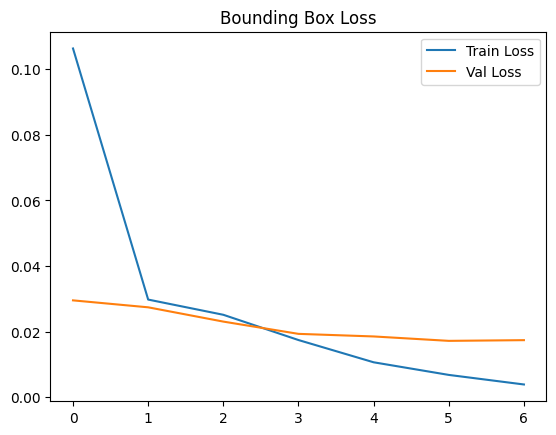

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Bounding Box Loss")
plt.show()


In [26]:
model.save("/content/drive/MyDrive/numberplate_detector.h5")


In [29]:
model.save_weights("/content/drive/MyDrive/numberplate_weights.weights.h5")

In [34]:
import os


model.save_weights("final_model_weights.weights.h5")


size_bytes = os.path.getsize("final_model_weights.weights.h5")


size_kb = size_bytes / 1024
size_mb = size_kb / 1024

print(f"Final Model Weight Size: {size_mb:.2f} MB")

Final Model Weight Size: 254.62 MB


In [36]:
print(image_path)
!ls /content/drive/MyDrive/numberplate/


/content/drive/MyDrive/numberplate/test.jpg
'number plate'
